# 05-Model Memory & Server Lifespans

In Lesson 04, we secured the perimeter of our API using Pydantic. We can mathematically guarantee that no malicious or malformed data will ever reach our GPU.

But now we face the most catastrophic architectural mistake made by junior AI engineers: **The VRAM Allocation Loop**.

If you are hosting a 15-Gigabyte Large Language Model, and you put the model-loading code *inside* your API route, your server is mathematically doomed. Let's set up our PyTorch and FastAPI environment to deconstruct memory lifespans and build an enterprise-grade model loader.

In [3]:
import torch
import torch.nn as nn
from fastapi import FastAPI
from contextlib import asynccontextmanager
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch, FastAPI, and Contextlib Environment Ready.")

✅ PyTorch, FastAPI, and Contextlib Environment Ready.


# 1. The Physics of the Anti-Pattern (The Memory Bomb)

Imagine you write this standard API route:

```python
@app.post("/generate")
async def generate_text(prompt: str):
    # DANGER: Loading the model INSIDE the route
    model = AutoModelForCausalLM.from_pretrained("llama-3-8b").cuda()
    return model.generate(prompt)
```

### The Latency Disaster

Loading a 15GB model from an SSD into GPU VRAM requires massive physical bandwidth (PCIe lanes). It typically takes between **5 to 15 seconds**.
If the loading code is inside the route, the user sends a request and must sit in silence for 15 seconds while the server reads the SSD, *before* the model even begins generating a single word.

### The Out-Of-Memory (OOM) Fatality

If 4 users hit this endpoint at the exact same millisecond, FastAPI will spin up 4 concurrent tasks.
Each task will attempt to allocate 15GB of VRAM.


$$4 \text{ users} \times 15\text{GB} = 60\text{GB of VRAM required}$$


A standard RTX 4090 only has 24GB. The GPU will instantly trigger a `CUDA Out of Memory` exception, halting the entire server, crashing the Python process, and dropping all 4 users simultaneously.


# 2. The Solution: The ASGI `lifespan` Protocol

To fix this, we must sever the model-loading physics from the API-routing physics.
We want the 15GB model to load exactly **once**—the moment the server boots up—and remain persistently lodged in VRAM as a global constant that all concurrent routes can share.

In modern FastAPI, the industry standard for this is the `@asynccontextmanager` called **`lifespan`**.

The `lifespan` function yields control in two distinct phases:

1. **The Setup (Pre-Yield)**: Code here runs *before* the server starts accepting HTTP requests. This is where we load the gigabytes of tensor weights. If the model fails to load, the server aborts booting, preventing users from connecting to a broken API.
2. **The Yield (`yield`)**: The server opens its ports and handles thousands of concurrent requests over days or weeks.
3. **The Teardown (Post-Yield)**: When the server is shut down (e.g., during a deployment update), the code resumes. This is where we execute `torch.cuda.empty_cache()` to physically wipe the VRAM clean so the next server can boot safely.

# 3. Architecting the Global Dictionary

How do the API routes access the model if it was loaded inside the lifespan function?
We initialize a global Python dictionary (e.g., `ml_models = {}`). During startup, we inject the massive PyTorch object into this dictionary. Because dictionaries in Python are passed by reference, the routes can access the 15GB model instantly ($O(1)$ lookup) without copying a single byte of memory.

# 4. Executing Lifespan Architecture in FastAPI

Let's build the exact enterprise skeleton required to host a massive neural network safely. We will simulate a heavy PyTorch initialization and track exactly when it occurs in the server's lifecycle.

*(Note: In a real environment, you run this file from the terminal using `uvicorn main:app`. For this notebook, we are architecting the code.)*

In [4]:
# --- ⚙️ main.py ---

# 1. Initialize the Global Memory Pointer
# This dictionary will hold our 15GB model reference
ml_models = {}

# 2. Architect the Lifespan Context Manager
@asynccontextmanager
async def lifespan(app: FastAPI):
    # ==========================================
    # PHASE 1: SERVER BOOT (PRE-YIELD)
    # ==========================================
    print("--- 🚀 SERVER BOOT INITIATED ---")
    print("1. Allocating GPU VRAM...")
    
    # Simulate loading a massive NLP model (Using a tiny linear layer for notebook safety)
    # In production: model = LlamaForCausalLM.from_pretrained("...").cuda()
    heavy_pytorch_model = nn.Linear(4096, 4096) 
    
    # Inject the model into the global dictionary
    ml_models["text_generator"] = heavy_pytorch_model
    print("2. Neural Network safely lodged in VRAM.")
    print("3. Opening HTTP Ports for incoming traffic...\n")
    
    # ==========================================
    # PHASE 2: THE YIELD (SERVER IS LIVE)
    # ==========================================
    yield  # The server pauses here and handles users for days/weeks/months
    
    # ==========================================
    # PHASE 3: SERVER SHUTDOWN (POST-YIELD)
    # ==========================================
    print("\n--- 🛑 SHUTDOWN SIGNAL RECEIVED ---")
    print("1. Disconnecting users...")
    
    # Destroy the Python pointer to the model
    ml_models.clear()
    
    # Physically wipe the GPU VRAM
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
    print("2. VRAM Wiped. Server gracefully terminated.")


# 3. Initialize FastAPI with the Lifespan binding
app = FastAPI(lifespan=lifespan)


# 4. The Inference Route
@app.post("/v1/generate")
async def generate_text(prompt: str):
    # A. Instant O(1) Lookup. Zero VRAM allocation overhead!
    model = ml_models["text_generator"]
    
    # B. Execute Inference
    # The model acts as a shared math engine for all concurrent users
    simulated_input = torch.randn(1, 4096)
    
    with torch.no_grad():
        output = model(simulated_input)
        
    return {"status": "success", "tensor_sum": output.sum().item()}

print("Success! Lifespan architecture compiled.")

Success! Lifespan architecture compiled.


# 5. Visualizing the VRAM Trajectory

To scientifically prove the superiority of the Lifespan architecture, we will use Matplotlib to plot the physical VRAM consumption of a server processing 5 concurrent requests over 10 seconds.

We will compare the **Anti-Pattern (Loading in Route)** against the **Lifespan Pattern**.

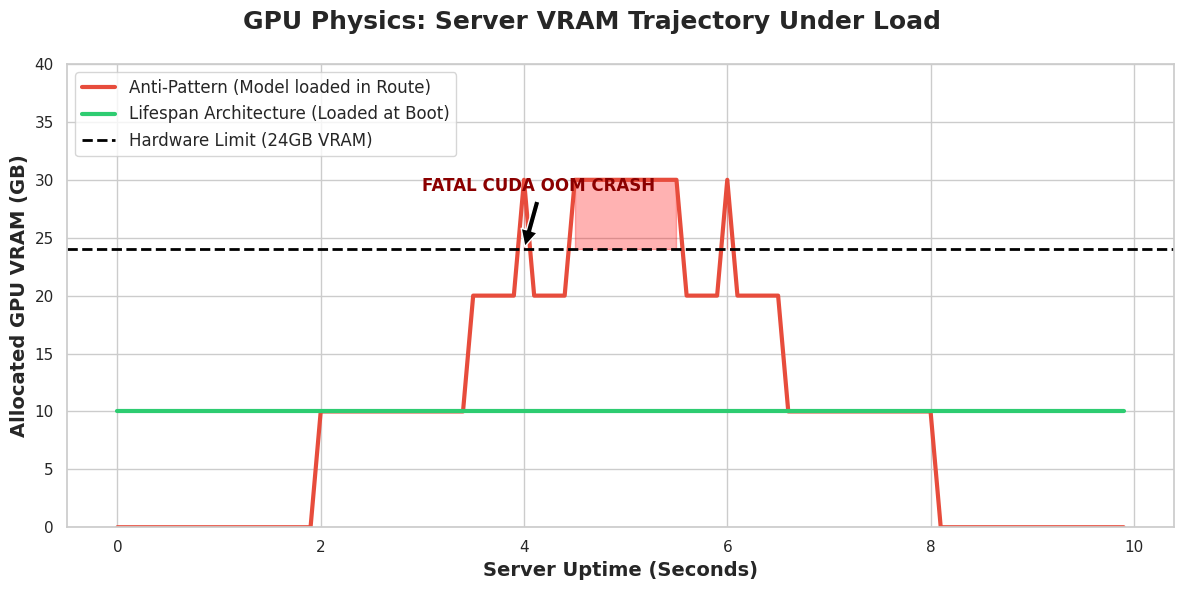


--- 💡 Engineering Insight ---
Look at the Red Line. At 2.0 seconds, User 1 hits the API. The route allocates 10GB. At 3.5s and 4.0s, Users 2 and 3 hit the API simultaneously. The server tries to allocate 30GB total, violently shattering the 24GB hardware limit and causing a catastrophic server crash.
Look at the Green Line. Using `lifespan`, the server claims 10GB at exactly 0.0 seconds. When Users 1, 2, and 3 hit the API, the memory footprint remains a perfectly flat line. The model acts as a shared mathematical constant, allowing 100 concurrent users to stream through the weights safely.


In [5]:
# 1. Define the Physics Simulation
time_steps = np.arange(0, 10, 0.1) # 10 seconds of server uptime
requests_arriving_at = [2.0, 3.5, 4.0, 4.5, 6.0] # Seconds when a user hits the API
model_size_gb = 10.0 # Our LLM is 10 GB
gpu_max_vram = 24.0  # RTX 4090 Limit

# 2. Simulate the Anti-Pattern (Loading in the route)
anti_pattern_vram = np.zeros_like(time_steps)
current_active_requests = 0

for i, t in enumerate(time_steps):
    # Check if a new request arrived
    if any(abs(t - req) < 0.05 for req in requests_arriving_at):
        current_active_requests += 1
        
    # The VRAM spikes by 10GB for EVERY active request!
    anti_pattern_vram[i] = current_active_requests * model_size_gb
    
    # Simulating request completion after 2 seconds
    if any(abs(t - (req + 2.0)) < 0.05 for req in requests_arriving_at):
        current_active_requests -= 1

# 3. Simulate the Lifespan Pattern
lifespan_vram = np.zeros_like(time_steps)
# At t=0 (Server Boot), the model loads exactly once
lifespan_vram[:] = model_size_gb 
# When requests hit, VRAM barely moves (maybe +0.1GB for the batch inference)

# 4. Render the VRAM Calculus
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("GPU Physics: Server VRAM Trajectory Under Load", fontsize=18, fontweight='bold')

# Plot the Anti-Pattern
ax.plot(time_steps, anti_pattern_vram, color='#e74c3c', linewidth=3, label="Anti-Pattern (Model loaded in Route)")

# Plot the Lifespan Pattern
ax.plot(time_steps, lifespan_vram, color='#2ecc71', linewidth=3, label="Lifespan Architecture (Loaded at Boot)")

# Draw the GPU Hardware Limit
ax.axhline(y=gpu_max_vram, color='black', linestyle='--', linewidth=2, label="Hardware Limit (24GB VRAM)")

# Annotate the crashes
ax.fill_between(time_steps, gpu_max_vram, anti_pattern_vram, where=(anti_pattern_vram > gpu_max_vram), color='red', alpha=0.3)
if np.max(anti_pattern_vram) > gpu_max_vram:
    crash_idx = np.argmax(anti_pattern_vram > gpu_max_vram)
    crash_time = time_steps[crash_idx]
    ax.annotate('FATAL CUDA OOM CRASH', xy=(crash_time, gpu_max_vram), xytext=(crash_time - 1, gpu_max_vram + 5),
                arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12, fontweight='bold', color='darkred')

ax.set_xlabel("Server Uptime (Seconds)", fontsize=14, fontweight='bold')
ax.set_ylabel("Allocated GPU VRAM (GB)", fontsize=14, fontweight='bold')
ax.set_ylim(0, 40)
ax.legend(loc="upper left", fontsize=12)

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look at the Red Line. At 2.0 seconds, User 1 hits the API. The route allocates 10GB. At 3.5s and 4.0s, Users 2 and 3 hit the API simultaneously. The server tries to allocate 30GB total, violently shattering the 24GB hardware limit and causing a catastrophic server crash.")
print("Look at the Green Line. Using `lifespan`, the server claims 10GB at exactly 0.0 seconds. When Users 1, 2, and 3 hit the API, the memory footprint remains a perfectly flat line. The model acts as a shared mathematical constant, allowing 100 concurrent users to stream through the weights safely.")

## Real-World Use Case or Analogy:

Think of the Lifespan protocol like **Operating a Commercial Airline**:

* **The Anti-Pattern (Building the Plane on the Runway)**: A passenger (The API Request) walks up to the gate with their ticket. The airline employees run out to the tarmac, smelt aluminum, construct a 747 jet engine from scratch (Loading the 10GB Model), put the passenger inside, and fly them to New York. When Passenger 2 arrives 5 minutes later, they construct a *second* 747 from scratch. The airport physically runs out of tarmac (VRAM) in 20 minutes, and every flight is delayed by 14 hours.
* **The Lifespan Protocol (The Hangar Initialization)**: At 4:00 AM, before any passengers are allowed inside the airport (Pre-Yield), the engineers pull the fully assembled 747 out of the hangar and leave its engines idling on the runway (Loading the model). At 6:00 AM, the doors open (The Yield). 300 passengers walk directly onto the plane and take off instantly. At midnight, when the airport closes, they turn the engine off and clean the plane (Post-Yield / Empty Cache).